# Part A - Analytical warm-up

Copilot question as starting point for formulas and code.


Documented in jupyter file:
    https://github.com/johtj/data_analysis_ml_projects/blob/main/assignment2/source/copilot_questions/cost_function.ipynb

### Hyperparameters relevant for cost functions
$y_i$ - Input data

$\tilde{y}_i$ - Predicted data

$n$ - number of datapoints

$\lambda_1$, $\lambda_2$ - Penalty term for L1 and L2 regularization

$|w_j|$ - absolute values of weights, used for L1 penalty

$w_j^2$ - squared values of weights, used for L2 penalty

L1 penalty driving weights towards zero, leding to a simpler model.

L2 penalty pushing weights to be small, leading to a smoother model.

Sign function that converts positive values to 1, negative values to -1, and keep 0 as 0.
\begin{equation}
\text{sign}(w_j) =
\begin{cases}
+1 & \text{if } w_j > 0 \\
-1 & \text{if } w_j < 0 \\
0 & \text{if } w_j = 0
\end{cases}
\end{equation}

### Mean Square Error

The mean of sum of residual between predicted and input data. Hence, a smaller value indicates a better fit.

Mean Square Error (MSE)
\begin{equation}
   \mathcal{L}_{\text{MSE}} = \frac{1}{n}
\sum_{i=0}^{n-1}(y_i-\tilde{y}_i)^2,
\end{equation}

MSE with L1 and L2 regularization
\begin{equation}
\mathcal{L}_{\text{MSE}}^{\text{reg}} = \mathcal{L}_{\text{MSE}} + \lambda_1 \sum_j |w_j| + \lambda_2 \sum_j w_j^2
\end{equation}

MSE derivative
\begin{equation}
\frac{\partial \mathcal{L}_{\text{MSE}}}{\partial \hat{y}_i} = \frac{2}{n} (\hat{y}_i - y_i)
\end{equation}

MSE derivative with penalty term
\begin{equation}
\frac{\partial \mathcal{L}_{\text{MSE}}^{\text{reg}}}{\partial w_j} = \frac{\partial \mathcal{L}_{\text{MSE}}}{\partial w_j} + \lambda_1 \cdot \text{sign}(w_j) + 2 \lambda_2 w_j
\end{equation}

### Binary Cross Entropy (Log Loss)

$y_i$ and $\tilde{y}_i$ are both $ \in (0,1)$

$\log(y_i)$ is logarithm true label for $i-th$ sample

$\log(\tilde{y_i})$ is logarithm predicted label for $i-th$ sample

$\log(1 - \hat{y}_i)$ is logarithm of the predicted probability for the negative class when the true label is 0.

Formula is summed and averaged over all samples. A smaller values indicates a better fit.

If $\log(y_i)$ = 1, penalizes low predicted probability for positive class.
If $\log(y_i)$ = 0, penalizes high predicted probability for positive class.

\begin{equation}
\mathcal{L}_{\text{BCE}} = -\frac{1}{n} \sum_{i=1}^{n} \left[ y_i \log(\hat{y}_i) + (1 - y_i) \log(1 - \hat{y}_i) \right]
\end{equation}

With L1 and L2 penalty terms
\begin{equation}
\mathcal{L}_{\text{BCE}}^{\text{reg}} = \mathcal{L}_{\text{BCE}} + \lambda_1 \sum_j |w_j| + \lambda_2 \sum_j w_j^2
\end{equation}

Derivative of binary cross-entropy
\begin{equation}
\frac{\partial \mathcal{L}_{\text{BCE}}}{\partial \hat{y}_i} = \frac{\hat{y}_i - y_i}{\hat{y}_i (1 - \hat{y}_i) n}
\end{equation}

Derivative of binary cross entropy with L1 and L2 penalty term
\begin{equation}
\frac{\partial \mathcal{L}_{\text{BCE}}^{\text{reg}}}{\partial w_j} = \frac{\partial \mathcal{L}_{\text{BCE}}}{\partial w_j} + \lambda_1 \cdot \text{sign}(w_j) + 2 \lambda_2 w_j
\end{equation}

### Multiclass Cross Entropy

Multiclass classification by using softmax and cross-entropy.

Softmax function. $z_i$ is the raw score (logit) if class $i$. $e^{z_j}$ is exponential opnential for raw score/logit. Softmax convert raw score to probabilities, sum of probabilities for all classes sums to 1.
\begin{equation}
\text{softmax}(z_i) = \frac{e^{z_i}}{\sum_{j} e^{z_j}}
\end{equation}

Multiclass cross-entropy. 

$K$ is numer of classes. $y_ik$ is true label, 1 if samle $i$ is in class, else 0. $\tilde{y_i}$ is predicted probability for class $k$, sample $i$. Summed and averaged over all classes and samples.
\begin{equation}
\mathcal{L}_{\text{CE}} = -\frac{1}{n} \sum_{i=1}^{n} \sum_{k=1}^{K} y_{ik} \log(\hat{y}_{ik})
\end{equation}

Penalty term L1 and L2 added to multiclass cross entropy. 
\begin{equation}
\mathcal{L}_{\text{CE}}^{\text{reg}} = \mathcal{L}_{\text{CE}} + \lambda_1 \sum_j |w_j| + \lambda_2 \sum_j w_j^2
\end{equation}

Derivative of multiclass cross entropy is simply 
$$
\frac{\partial \mathcal{L}}{\partial z_j} = s_j \cdot \sum_{i=1}^{c} y_i - y_j = s_j - y_j
$$
$z_j$ is the raw score/logits for class $j$. $s_j$ is the corresponding softmax probability. While $y_j$ is prediced probability.


See: https://medium.com/data-science/derivative-of-the-softmax-function-and-the-categorical-cross-entropy-loss-ffceefc081d1

With L1 and L2 penalty term
\begin{equation}
\frac{\partial \mathcal{L}_{\text{CE}}^{\text{reg}}}{\partial w_j} = \frac{\partial \mathcal{L}}{\partial z_j} + \lambda_1 \cdot \text{sign}(w_j) + 2 \lambda_2 w_j
\end{equation}



In [1]:
# imports
import autograd.numpy as np 
import matplotlib.pyplot as plt

# custom imports
import source.activation_functions as activation_functions
from source.runge_preprocessing import x_train_scaled


In [2]:
# same z for all plots of activation functions
z = np.arange(-5, 5, .1)


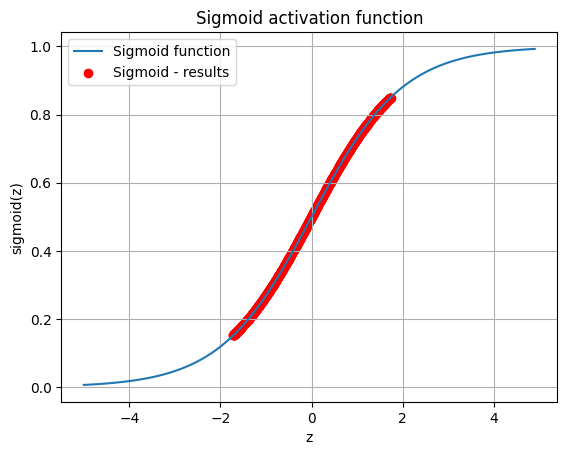

In [3]:
# Sigmoid activation function

sigmoid_function = activation_functions.sigmoid(z)

# sigmoid results
sigmoid_results = activation_functions.sigmoid(x_train_scaled)

plt.plot(z, sigmoid_function, label='Sigmoid function')
plt.scatter(x_train_scaled, sigmoid_results, label='Sigmoid - results', color='red')
plt.grid(True)
plt.xlabel('z')
plt.ylabel('sigmoid(z)')
plt.title('Sigmoid activation function')
plt.legend()
plt.show()

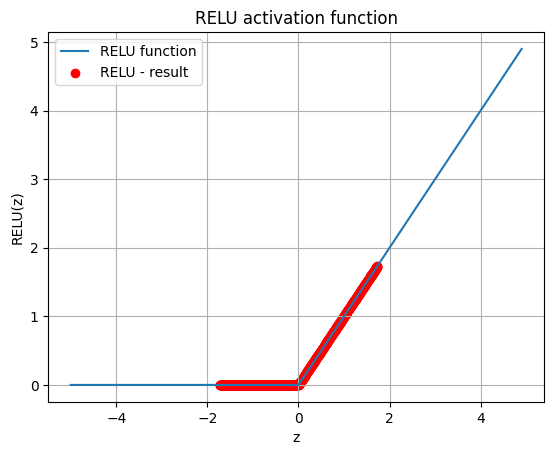

In [4]:
# RELU activation function


relu_function = activation_functions.RELU(z)

# sigmoid results
relu_results = activation_functions.RELU(x_train_scaled)

plt.plot(z, relu_function, label='RELU function')
plt.scatter(x_train_scaled, relu_results, label='RELU - result', color='red')
plt.grid(True)
plt.xlabel('z')
plt.ylabel('RELU(z)')
plt.title('RELU activation function')
plt.legend()
plt.show()




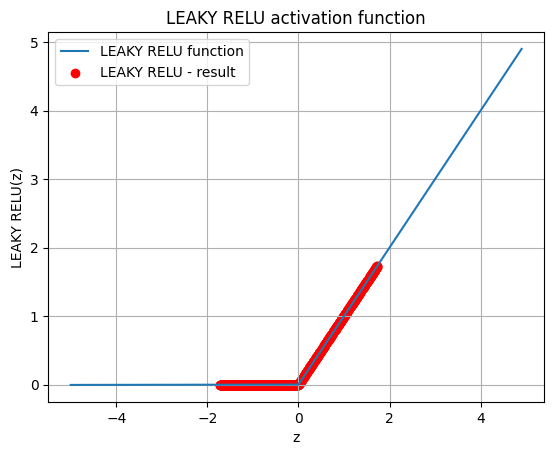

In [5]:
# LEAKY RELU activation function


leakyrelu_function = activation_functions.LRELU(z)

# sigmoid from y_noise
relu_results = activation_functions.LRELU(x_train_scaled)

plt.plot(z, leakyrelu_function, label='LEAKY RELU function')
plt.scatter(x_train_scaled, relu_results, label='LEAKY RELU - result', color='red')
plt.grid(True)
plt.xlabel('z')
plt.ylabel('LEAKY RELU(z)')
plt.title('LEAKY RELU activation function')
plt.legend()
plt.show()

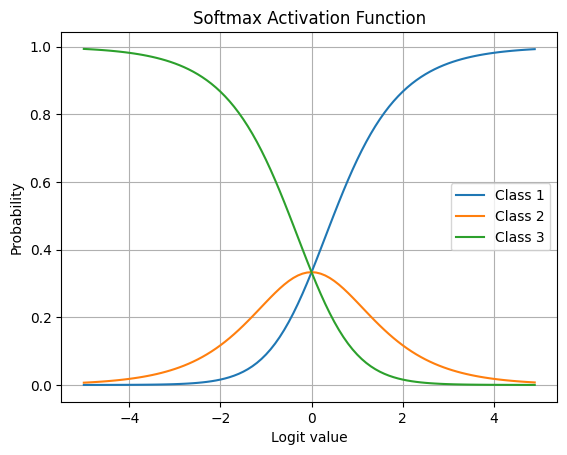

In [6]:
# Softmax activation function


softmax_function = activation_functions.softmax(z)

# simulate 3 classes
softmax_values = [activation_functions.softmax([val, 0, -val]) for val in z]  

softmax_values = np.array(softmax_values)

# check that row sums to 1
#row_sums = softmax_values.sum(axis=1)
#print(row_sums)

plt.plot(z, softmax_values[:, 0], label='Class 1')
plt.plot(z, softmax_values[:, 1], label='Class 2')
plt.plot(z, softmax_values[:, 2], label='Class 3')
plt.title('Softmax Activation Function')
plt.xlabel('Logit value')
plt.ylabel('Probability')
plt.grid(True)
plt.legend()
plt.show()
